# AI Spending Sentiment Analysis — SEC EDGAR 10-Q Filings (Live Fetch)

**Companies:** Alphabet (GOOGL), Amazon (AMZN), Meta (META), Oracle (ORCL), Nvidia (NVDA)

This notebook pulls each company's most recently filed 10-Q directly from SEC EDGAR via `requests`, filters for sentences on AI spending and runs sentiment analysis on those sentences with FinBERT.

## 0. Install & import dependencies

In [1]:
!pip install -q transformers torch beautifulsoup4 lxml nltk requests pandas matplotlib


In [2]:
import re
import time
import warnings
from pathlib import Path

import pandas as pd
import requests
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.tokenize import sent_tokenize

from transformers import pipeline

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)


## 1. Configuration

`SEC_USER_AGENT` is required by SEC on every request to `sec.gov` / `data.sec.gov`. A name/company and a contact email is needed.

CIKs are permanent identifiers for SEC data.

In [3]:
SEC_USER_AGENT = ...  # <-- replace with name and email before running

COMPANIES = {
    "0001652044": {"ticker": "GOOGL", "name": "Alphabet"},
    "0001018724": {"ticker": "AMZN",  "name": "Amazon"},
    "0001326801": {"ticker": "META",  "name": "Meta"},
    "0001341439": {"ticker": "ORCL",  "name": "Oracle"},
    "0001045810": {"ticker": "NVDA",  "name": "Nvidia"},
}


In [4]:
def sec_get(url: str, **kwargs) -> requests.Response:
    headers = {"User-Agent": SEC_USER_AGENT, "Accept-Encoding": "gzip, deflate"}
    resp = requests.get(url, headers=headers, timeout=30, **kwargs)
    resp.raise_for_status()
    time.sleep(0.2)  # stay under SEC's rate limit
    return resp


def get_latest_10q(cik: str) -> dict | None:
    """Return metadata for a company's most recently filed 10-Q, or None."""
    url = f"https://data.sec.gov/submissions/CIK{cik}.json"
    data = sec_get(url).json() # requests.get() function 

    recent = data["filings"]["recent"]
    rows = pd.DataFrame({
        "form": recent["form"],
        "accessionNumber": recent["accessionNumber"], # unique document identifier
        "primaryDocument": recent["primaryDocument"],
        "filingDate": recent["filingDate"],
        "reportDate": recent["reportDate"],
    })

    tenq = rows[rows["form"] == "10-Q"].sort_values("filingDate", ascending=False)
    if tenq.empty:
        return None

    row = tenq.iloc[0] # getting the most recent filing
    return {
        "cik": cik,
        "accessionNumber": row["accessionNumber"],
        "primaryDocument": row["primaryDocument"],
        "filingDate": row["filingDate"],
        "reportDate": row["reportDate"],
    }


filings = {}
for cik, info in COMPANIES.items():
    meta = get_latest_10q(cik)
    filings[cik] = meta
    if meta:
        print(f"{info['ticker']:6s} ({info['name']:9s}): 10-Q filed {meta['filingDate']} "
              f"for period ending {meta['reportDate']}  [{meta['accessionNumber']}]")
    else:
        print(f"{info['ticker']:6s} ({info['name']:9s}): NO 10-Q found in recent filings")


GOOGL  (Alphabet ): 10-Q filed 2026-04-30 for period ending 2026-03-31  [0001652044-26-000048]


AMZN   (Amazon   ): 10-Q filed 2026-04-30 for period ending 2026-03-31  [0001018724-26-000014]


META   (Meta     ): 10-Q filed 2026-04-30 for period ending 2026-03-31  [0001628280-26-028526]


ORCL   (Oracle   ): 10-Q filed 2026-03-11 for period ending 2026-02-28  [0001193125-26-101045]


NVDA   (Nvidia   ): 10-Q filed 2026-05-20 for period ending 2026-04-26  [0001045810-26-000052]


In [5]:
def fetch_filing_text(cik: str, accession_number: str, primary_document: str) -> str:
    cik_int = str(int(cik))  # archive URLs use CIK without leading zeros
    accession_nodash = accession_number.replace("-", "")
    doc_url = (
        f"https://www.sec.gov/Archives/edgar/data/{cik_int}/"
        f"{accession_nodash}/{primary_document}" # proper formatting for fetching the text
    )
    try:
        html = sec_get(doc_url).text
    except Exception as e:
        print(f"  could not fetch {doc_url}: {e}")
        return ""

    soup = BeautifulSoup(html, "lxml") # scrapes html to get text
    for tag_el in soup(["script", "style", "table"]):
        tag_el.decompose()
    text = re.sub(r"\s+", " ", soup.get_text(separator=" ")).strip()
    return text


company_text = {}
for cik, info in COMPANIES.items():
    meta = filings.get(cik)
    if not meta:
        company_text[info["ticker"]] = ""
        continue
    print(f"Fetching {info['ticker']} 10-Q text ...")
    text = fetch_filing_text(cik, meta["accessionNumber"], meta["primaryDocument"])
    company_text[info["ticker"]] = text
    print(f"  -> {len(text):,} characters" if text else "  -> FAILED / empty")


Fetching GOOGL 10-Q text ...


  -> 150,101 characters
Fetching AMZN 10-Q text ...


  -> 175,030 characters
Fetching META 10-Q text ...


  -> 381,998 characters
Fetching ORCL 10-Q text ...


  -> 155,486 characters
Fetching NVDA 10-Q text ...


  -> 136,501 characters


## 4. Extract AI-spending sentences

A sentence must reference AI in some form and a spending / infrastructure /
investment term, so we don't pull in unrelated "AI" mentions (e.g. product feature
lists) that say nothing about spend.

In [6]:
AI_TERMS = [
    r"\bartificial intelligence\b",
    r"\bgenerative ai\b",
    r"\bAI\b",
    r"\bmachine learning\b",
    r"\bML models?\b",
    r"\blarge language models?\b",
    r"\bLLMs?\b",
]

SPEND_TERMS = [
    r"\bcapital expenditures?\b",
    r"\bcapex\b",
    r"\binvest(?:ing|ment|ments)?\b",
    r"\bspend(?:ing)?\b",
    r"\bdata center(?:s)?\b",
    r"\binfrastructure\b",
    r"\bGPUs?\b",
    r"\bcompute capacity\b",
    r"\bcloud infrastructure\b",
    r"\bchips?\b",
    r"\bbuild(?:ing|out)? (?:out )?(?:data center|infrastructure|capacity)\b",
    r"\bOCI\b",                          # Oracle Cloud Infrastructure
    r"\bOracle Cloud Infrastructure\b",
    r"\baccelerated computing\b",
    r"\bAI workloads?\b",
]

AI_RE = re.compile("|".join(AI_TERMS), flags=re.IGNORECASE)
SPEND_RE = re.compile("|".join(SPEND_TERMS), flags=re.IGNORECASE)


def extract_ai_spending_sentences(text: str, min_len: int = 40, max_len: int = 600):
    sentences = sent_tokenize(text)
    hits = [
        s.strip() for s in sentences
        if min_len <= len(s.strip()) <= max_len
        and AI_RE.search(s) and SPEND_RE.search(s)
    ]
    seen, deduped = set(), [] # handles duplicates
    for s in hits:
        if s not in seen:
            seen.add(s)
            deduped.append(s)
    return deduped


ai_spending_sentences = {}
for ticker, text in company_text.items():
    sents = extract_ai_spending_sentences(text)
    ai_spending_sentences[ticker] = sents
    print(f"{ticker:6s}: {len(sents):>4} AI-spending sentences found")


GOOGL :    5 AI-spending sentences found
AMZN  :    6 AI-spending sentences found
META  :   17 AI-spending sentences found
ORCL  :    0 AI-spending sentences found
NVDA  :   16 AI-spending sentences found


## 5. Load FinBERT and score sentiment

[`ProsusAI/finbert`](https://huggingface.co/ProsusAI/finbert) — a BERT model fine-tuned
on financial text for 3-way sentiment (`positive` / `negative` / `neutral`).

In [7]:
finbert = pipeline(
    task="sentiment-analysis",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert",
    truncation=True,
    max_length=512,
)

TICKER_TO_NAME = {v["ticker"]: v["name"] for v in COMPANIES.values()}

records = []
for ticker, sentences in ai_spending_sentences.items():
    if not sentences:
        continue
    results = finbert(sentences, batch_size=16)
    for sent, res in zip(sentences, results):
        records.append({
            "ticker": ticker,
            "company": TICKER_TO_NAME[ticker],
            "sentence": sent,
            "label": res["label"],
            "score": res["score"],
        })

df = pd.DataFrame(records)
print(f"Total AI-spending sentences scored: {len(df)}")
df.head(10)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Total AI-spending sentences scored: 44


,ticker,company,sentence,label,score
0,GOOGL,Alphabet,This acquisition represents an investment by Google Cloud to accelerate our capabilities in multicloud and artificia...,positive,0.877545
1,GOOGL,Alphabet,"These costs primarily include: • certain AI-focused shared research and development activities, including employee c...",neutral,0.867654
2,GOOGL,Alphabet,"These services provide access to solutions such as AI offerings including our enterprise AI infrastructure, Vertex A...",neutral,0.823819
3,GOOGL,Alphabet,"The investments that we are making across our businesses — such as building AI-optimized infrastructure, including o...",positive,0.649112
4,GOOGL,Alphabet,"49 To meet the AI compute capacity demands of our customers, we are engaging in the supply of our custom hardware wh...",negative,0.699764
5,AMZN,Amazon,"Further, we expect to continue making additional investments in our artificial intelligence initiatives.",positive,0.810342
6,AMZN,Amazon,We expect spending in technology and infrastructure to increase over time as we continue to add infrastructure and e...,positive,0.923029
7,AMZN,Amazon,"In addition, new and enhanced technologies, including search, web and infrastructure computing services, practical a...",positive,0.653686
8,AMZN,Amazon,"In addition, profitability or other intended benefits, if any, in our newer activities (including development and ad...",negative,0.756001
9,AMZN,Amazon,"Operating Risks Our Expansion Places a Significant Strain on our Management, Operational, Financial, and Other Resou...",positive,0.811406


## 6. Aggregate sentiment by company

- counts of positive / negative / neutral sentences
- **net sentiment** = (positive − negative) / total mentions
- average model confidence

In [8]:
def summarize(group: pd.DataFrame) -> pd.Series:
    counts = group["label"].value_counts()
    pos, neg, neu = counts.get("positive", 0), counts.get("negative", 0), counts.get("neutral", 0)
    total = len(group)
    net_sentiment = (pos - neg) / total if total else 0.0
    return pd.Series({
        "n_mentions": total, "positive": pos, "neutral": neu, "negative": neg,
        "net_sentiment": round(net_sentiment, 3),
        "avg_confidence": round(group["score"].mean(), 3) if total else 0.0,
    })

company_order = [v["name"] for v in COMPANIES.values()]
summary = (
    df.groupby("company", group_keys=False).apply(summarize)
      .reindex(company_order)
)
summary


,n_mentions,positive,neutral,negative,net_sentiment,avg_confidence
company,,,,,,
Alphabet,5.0,2.0,2.0,1.0,0.200,0.784
Amazon,6.0,4.0,1.0,1.0,0.500,0.813
Meta,17.0,14.0,1.0,2.0,0.706,0.848
Oracle,NaN,NaN,NaN,NaN,NaN,NaN
Nvidia,16.0,5.0,5.0,6.0,-0.062,0.857


## 7. Visualize: net sentiment and label mix per company

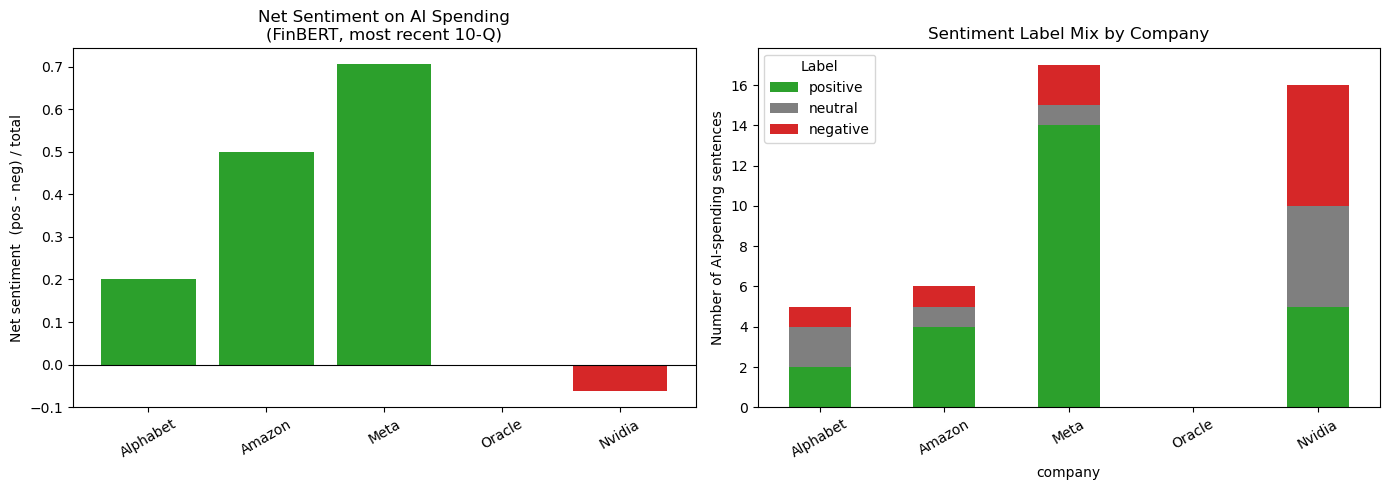

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#2ca02c" if v >= 0 else "#d62728" for v in summary["net_sentiment"].fillna(0)]
axes[0].bar(summary.index, summary["net_sentiment"].fillna(0), color=colors)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Net Sentiment on AI Spending\n(FinBERT, most recent 10-Q)")
axes[0].set_ylabel("Net sentiment  (pos - neg) / total")
axes[0].tick_params(axis="x", rotation=30)

stacked = summary[["positive", "neutral", "negative"]].fillna(0)
stacked.plot(kind="bar", stacked=True, ax=axes[1], color=["#2ca02c", "#7f7f7f", "#d62728"])
axes[1].set_title("Sentiment Label Mix by Company")
axes[1].set_ylabel("Number of AI-spending sentences")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Label")

plt.tight_layout()
plt.show()


## 9. Top positive / negative sentences per company

In [10]:
for cik, info in COMPANIES.items():
    ticker, company = info["ticker"], info["name"]
    sub_df = df[df["company"] == company]
    print(f"\n=== {company} ({ticker}) ===")
    if sub_df.empty:
        print("  no AI-spending sentences found")
        continue
    for _, r in sub_df[sub_df["label"] == "positive"].sort_values("score", ascending=False).head(2).iterrows():
        print(f"  [+{r['score']:.2f}] {r['sentence']}")
    for _, r in sub_df[sub_df["label"] == "negative"].sort_values("score", ascending=False).head(2).iterrows():
        print(f"  [-{r['score']:.2f}] {r['sentence']}")



=== Alphabet (GOOGL) ===
  [+0.88] This acquisition represents an investment by Google Cloud to accelerate our capabilities in multicloud and artificial intelligence (AI)-driven security.
  [+0.65] The investments that we are making across our businesses — such as building AI-optimized infrastructure, including our custom TPUs, and integrating AI capabilities into new and existing products and services — reflect our ongoing efforts to innovate and provide products and services that are helpful to users, advertisers, publishers, customers, content providers, and distribution partners.
  [-0.70] 49 To meet the AI compute capacity demands of our customers, we are engaging in the supply of our custom hardware which may increase our costs and operational complexity.

=== Amazon (AMZN) ===
  [+0.92] We expect spending in technology and infrastructure to increase over time as we continue to add infrastructure and employees, including to support our artificial intelligence and machine learnin

## 10. CapEx history

In [11]:
def find_capex_tags(company_facts: dict) -> list[str]:
    """Search a company's full XBRL facts for any tag that looks like capital expenditures."""
    us_gaap = company_facts.get("facts", {}).get("us-gaap", {})
    return [
        tag for tag in us_gaap
        if re.search(r"PropertyPlantAndEquipment|ProductiveAssets", tag)
        and re.search(r"Payments|Purchase", tag, re.IGNORECASE)
    ]


def get_capex_history_auto(cik: str) -> pd.DataFrame:
    """Fetch capex history, automatically merging across any tag the company has used over time (ex: AMZN and NVDA changed over time,
    and converting YTD-cumulative cash-flow figures into standalone quarterly values."""
    url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json"
    try:
        data = sec_get(url).json()
    except Exception as e:
        print(f"  could not fetch companyfacts for CIK {cik}: {e}")
        return pd.DataFrame()

    candidate_tags = find_capex_tags(data)
    print(f"  candidate capex tags found: {candidate_tags}")

    all_quarterly = []
    for tag in candidate_tags:
        facts = data["facts"]["us-gaap"][tag].get("units", {}).get("USD", [])
        if not facts:
            continue
        df_facts = pd.DataFrame(facts)

        if "start" not in df_facts.columns:
            print(f"    skipping '{tag}' -- instant concept, no start date")
            continue

        df_facts = df_facts[df_facts["form"].isin(["10-Q", "10-K"])].copy()
        df_facts = df_facts.dropna(subset=["start", "end"])
        if df_facts.empty:
            continue

        df_facts["start"] = pd.to_datetime(df_facts["start"])
        df_facts["end"] = pd.to_datetime(df_facts["end"])
        df_facts = (
            df_facts.sort_values("filed")
                    .drop_duplicates(subset=["start", "end"], keep="last")
                    .sort_values("end").reset_index(drop=True)
        )

        df_facts["quarterly_val"] = 0.0
        for _, group in df_facts.groupby("start"):
            group = group.sort_values("end")
            prev_val = 0.0
            for idx in group.index:
                df_facts.loc[idx, "quarterly_val"] = df_facts.loc[idx, "val"] - prev_val
                prev_val = df_facts.loc[idx, "val"]

        df_facts["tag"] = tag
        all_quarterly.append(df_facts)

    if not all_quarterly:
        return pd.DataFrame()

    combined = pd.concat(all_quarterly, ignore_index=True)
    combined = (
        combined.sort_values("filed")
                .drop_duplicates(subset=["end"], keep="last")
                .sort_values("end").reset_index(drop=True)
    )
    return combined


capex_history = {}
for cik, info in COMPANIES.items():
    print(f"Fetching CapEx history for {info['ticker']} ...")
    capex_history[info["ticker"]] = get_capex_history_auto(cik)

# Sanity check for diff artifacts before trusting the chart
for ticker, hist in capex_history.items():
    bad = hist[hist.get("quarterly_val", pd.Series(dtype=float)) < 0] if not hist.empty else pd.DataFrame()
    if not bad.empty:
        print(f"  {ticker}: {len(bad)} NEGATIVE quarterly value(s) -- possible diff artifact, inspect before publishing")

Fetching CapEx history for GOOGL ...


  candidate capex tags found: ['PaymentsToAcquirePropertyPlantAndEquipment']
Fetching CapEx history for AMZN ...


  candidate capex tags found: ['BusinessAcquisitionPurchasePriceAllocationPropertyPlantAndEquipment', 'PaymentsForProceedsFromProductiveAssets', 'PaymentsToAcquireProductiveAssets', 'PaymentsToAcquirePropertyPlantAndEquipment']
    skipping 'BusinessAcquisitionPurchasePriceAllocationPropertyPlantAndEquipment' -- instant concept, no start date
Fetching CapEx history for META ...


  candidate capex tags found: ['PaymentsToAcquirePropertyPlantAndEquipment']
Fetching CapEx history for ORCL ...


  candidate capex tags found: ['PaymentsForProceedsFromProductiveAssets', 'PaymentsToAcquirePropertyPlantAndEquipment']
Fetching CapEx history for NVDA ...


  candidate capex tags found: ['BusinessAcquisitionPurchasePriceAllocationPropertyPlantAndEquipment', 'PaymentsToAcquireProductiveAssets', 'PaymentsToAcquirePropertyPlantAndEquipment']
    skipping 'BusinessAcquisitionPurchasePriceAllocationPropertyPlantAndEquipment' -- instant concept, no start date


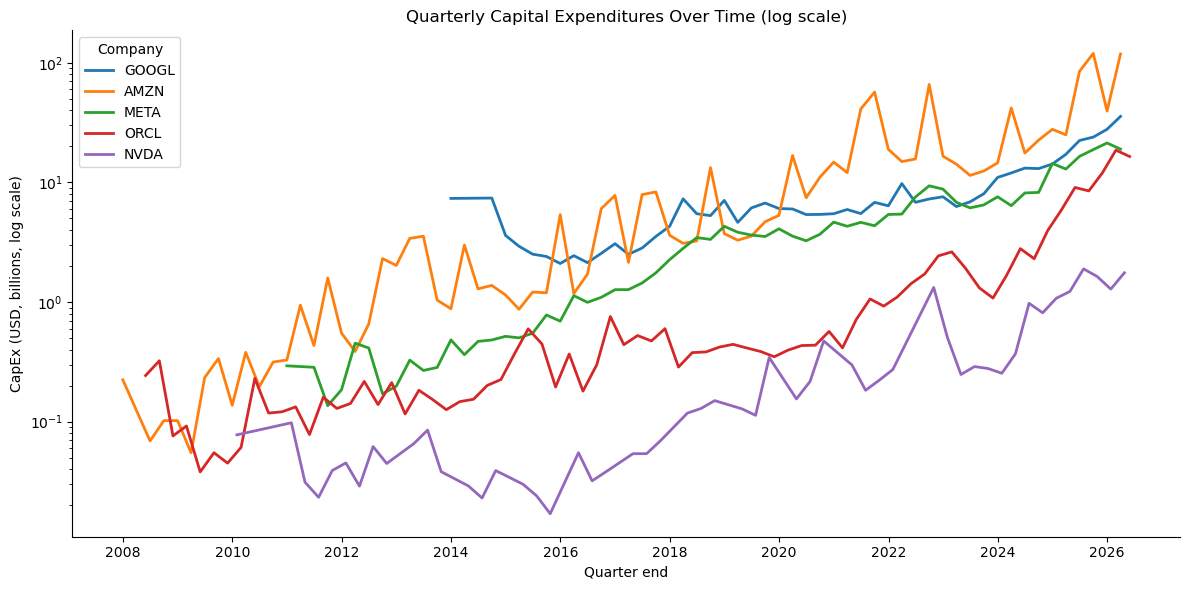

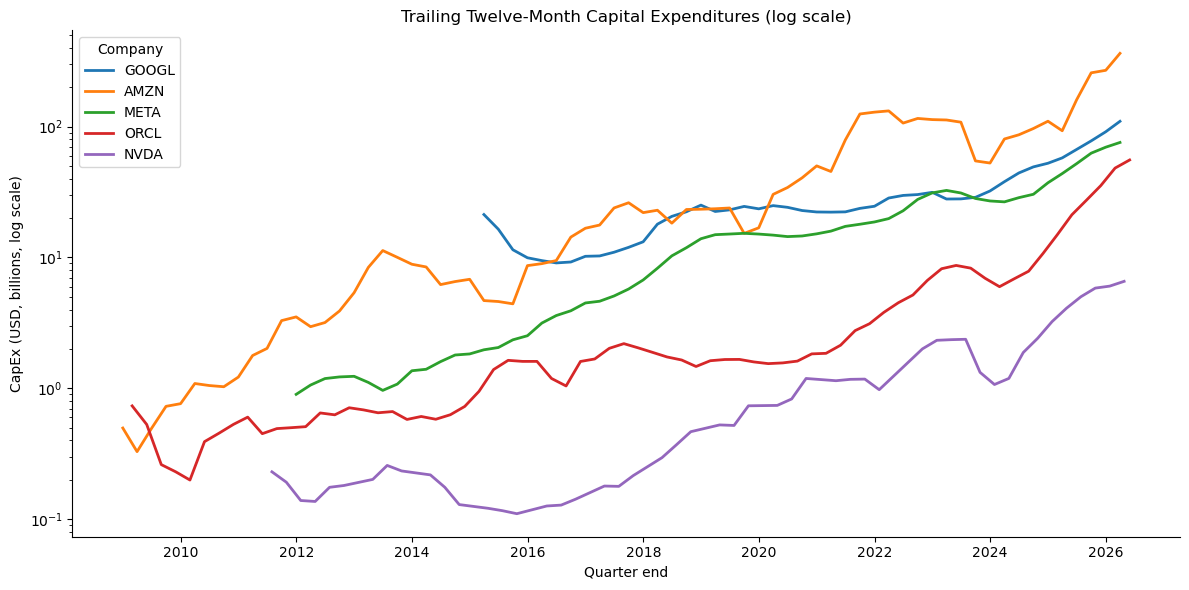

In [12]:
# --- One combined chart, all five companies, raw quarterly CapEx (log scale, clean lines) ---
fig, ax = plt.subplots(figsize=(12, 6))
for ticker, hist in capex_history.items():
    if hist.empty or "quarterly_val" not in hist.columns:
        print(f"  no usable CapEx data for {ticker}")
        continue
    plot_data = hist[hist["quarterly_val"] > 0]  # log scale can't show zero/negative values
    ax.plot(plot_data["end"], plot_data["quarterly_val"] / 1e9, label=ticker, linewidth=2)

ax.set_yscale("log")
ax.set_title("Quarterly Capital Expenditures Over Time (log scale)")
ax.set_xlabel("Quarter end")
ax.set_ylabel("CapEx (USD, billions, log scale)")
ax.legend(title="Company")
ax.grid(False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

# --- Same five companies, trailing-twelve-month view for a smoother trend line ---
fig, ax = plt.subplots(figsize=(12, 6))
for ticker, hist in capex_history.items():
    if hist.empty or "quarterly_val" not in hist.columns:
        continue
    hist = hist.sort_values("end").copy()
    hist["ttm_val"] = hist["quarterly_val"].rolling(window=4, min_periods=4).sum()
    plot_data = hist[hist["ttm_val"] > 0]
    ax.plot(plot_data["end"], plot_data["ttm_val"] / 1e9, label=ticker, linewidth=2)

ax.set_yscale("log")
ax.set_title("Trailing Twelve-Month Capital Expenditures (log scale)")
ax.set_xlabel("Quarter end")
ax.set_ylabel("CapEx (USD, billions, log scale)")
ax.legend(title="Company")
ax.grid(False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## Saving results

In [13]:
df.to_csv("ai_spending_sentences_scored.csv", index=False)
pd.concat([hist.assign(ticker=ticker) for ticker, hist in capex_history.items() if not hist.empty], ignore_index=True).to_csv("capex_history.csv", index=False)